In [1]:
# Experiment 4

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("all_space_mission_launches.csv")

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,Unnamed: 0,Organisation,Location,Datetime,Details,Rocket_Status,Price,Mission_Status
0,0,VKS RF,"Site 43/4, Plesetsk Cosmodrome, Russia","Fri Feb 09, 2024 07:03 UTC",Soyuz 2.1v | Cosmos 2575,Active,NaN,Success
1,1,SpaceX,"SLC-40, Cape Canaveral SFS, Florida, USA","Thu Feb 08, 2024 06:33 UTC",Falcon 9 Block 5 | PACE,Active,67.0,Success
2,2,CASC,"Bo Run Jiu Zhou Barge (Area 2), China Coastal ...","Sat Feb 03, 2024 03:06 UTC",Jielong-3 | 9 satellites,Active,NaN,Success
3,3,CASC,"LC-3, Xichang Satellite Launch Center, China","Fri Feb 02, 2024 23:37 UTC",Long March 2C | Geely Constellation Group 02,Active,30.8,Success
4,4,Rocket Lab,"Rocket Lab LC-1B, Māhia Peninsula, New Zealand","Wed Jan 31, 2024 06:34 UTC",Electron/Curie | Four Of A Kind,Active,7.5,Success


In [5]:
print("Rows :", df.shape[0])      #Dataset Shape and Column names
print("Columns :", df.shape[1])
print(df.columns.tolist())

Rows : 6711
Columns : 8
['Unnamed: 0', 'Organisation', 'Location', 'Datetime', 'Details', 'Rocket_Status', 'Price', 'Mission_Status']


In [6]:
df.dtypes    #Display Data Types

Unnamed: 0          int64
Organisation       object
Location           object
Datetime           object
Details            object
Rocket_Status      object
Price             float64
Mission_Status     object
dtype: object

In [8]:
df.describe(include='all')     #Statistical Summary

,Unnamed: 0,Organisation,Location,Datetime,Details,Rocket_Status,Price,Mission_Status
count,6711.000000,6711,6711,6711,6711,6711,2637.000000,6711
unique,NaN,66,166,6710,6666,2,NaN,4
top,NaN,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Tue Feb 05, 2019 21:01 UTC",Soyuz U | Resurs-F,Retired,NaN,Success
freq,NaN,2476,487,2,20,5240,NaN,6134
mean,654.061243,NaN,NaN,NaN,NaN,NaN,69.162321,NaN
std,423.680057,NaN,NaN,NaN,NaN,NaN,101.440856,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN,2.500000,NaN
25%,279.000000,NaN,NaN,NaN,NaN,NaN,20.000000,NaN
50%,611.000000,NaN,NaN,NaN,NaN,NaN,30.000000,NaN
75%,1005.000000,NaN,NaN,NaN,NaN,NaN,67.000000,NaN


In [9]:
print(df.select_dtypes(include=np.number).columns.tolist())     #Display Numerical Columns

['Unnamed: 0', 'Price']


In [10]:
print(df.select_dtypes(include='object').columns.tolist())      #Display Categorical Columns

['Organisation', 'Location', 'Datetime', 'Details', 'Rocket_Status', 'Mission_Status']


In [13]:
company_data = df[df["Organisation"] == df["Organisation"].iloc[0]]

company_data.head()          #Filter Data

,Unnamed: 0,Organisation,Location,Datetime,Details,Rocket_Status,Price,Mission_Status
0,0,VKS RF,"Site 43/4, Plesetsk Cosmodrome, Russia","Fri Feb 09, 2024 07:03 UTC",Soyuz 2.1v | Cosmos 2575,Active,NaN,Success
30,30,VKS RF,"Site 43/4, Plesetsk Cosmodrome, Russia","Wed Dec 27, 2023 07:03 UTC",Soyuz 2.1v | Cosmos 2574,Active,NaN,Success
38,38,VKS RF,"Site 43/4, Plesetsk Cosmodrome, Russia","Thu Dec 21, 2023 08:48 UTC",Soyuz 2.1b | Cosmos 2573,Active,20.0,Success
58,58,VKS RF,"Site 43/4, Plesetsk Cosmodrome, Russia","Sat Nov 25, 2023 20:58 UTC",Soyuz 2.1b | Cosmos 2572,Active,20.0,Success
77,77,VKS RF,"Site 43/3, Plesetsk Cosmodrome, Russia","Fri Oct 27, 2023 06:04 UTC",Soyuz 2.1b | Cosmos 2570,Active,20.0,Success


In [14]:
sorted_df = df.sort_values(by="Price", ascending=False)       #Sort Dataset

sorted_df.head()

,Unnamed: 0,Organisation,Location,Datetime,Details,Rocket_Status,Price,Mission_Status
284,284,NASA,"LC-39B, Kennedy Space Center, Florida, USA","Wed Nov 16, 2022 06:47 UTC",SLS Block 1 | Artemis I,Active,876.0,Success
2354,854,NASA,"LC-39B, Kennedy Space Center, Florida, USA","Thu May 27, 1999 10:49 UTC",Space Shuttle Discovery | STS-96,Retired,450.0,Success
1651,151,NASA,"LC-39A, Kennedy Space Center, Florida, USA","Mon Nov 16, 2009 19:28 UTC",Space Shuttle Atlantis | STS-129,Retired,450.0,Success
2915,1415,NASA,"LC-39B, Kennedy Space Center, Florida, USA","Thu Oct 22, 1992 17:09 UTC",Space Shuttle Columbia | STS-52,Retired,450.0,Success
2899,1399,NASA,"LC-39A, Kennedy Space Center, Florida, USA","Wed Dec 02, 1992 13:24 UTC",Space Shuttle Discovery | STS-53,Retired,450.0,Success


In [15]:
column = "Price"                             #Mean, Median, Mode and Standard Deviation

print("Mean :", df[column].mean())
print("Median :", df[column].median())
print("Mode :")
print(df[column].mode())

print("Standard Deviation :", df[column].std())

Mean : 69.16232081911254
Median : 30.0
Mode :
0    20.0
Name: Price, dtype: float64
Standard Deviation : 101.44085589264591


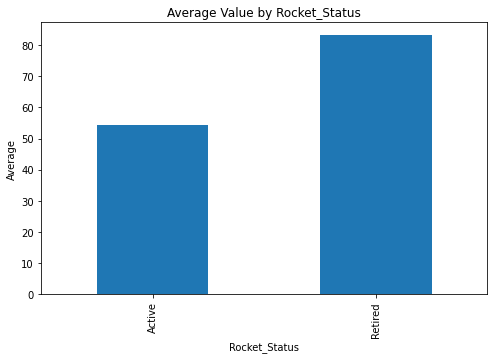

In [31]:
grouped.head(10).plot(kind="bar", figsize=(8,5))            #Bar Chart

plt.title("Average Value by Rocket_Status")

plt.xlabel("Rocket_Status")

plt.ylabel("Average")

plt.show()

In [27]:
grouped = df.groupby("Rocket_Status")[column].mean()      #Grouping and Aggregation

print(grouped)

Rocket_Status
Active     54.399782
Retired    83.150753
Name: Price, dtype: float64


In [32]:
corr = df.select_dtypes(include=np.number).corr()       #Correlation Matrix

print(corr)

            Unnamed: 0    Price
Unnamed: 0     1.00000  0.05205
Price          0.05205  1.00000


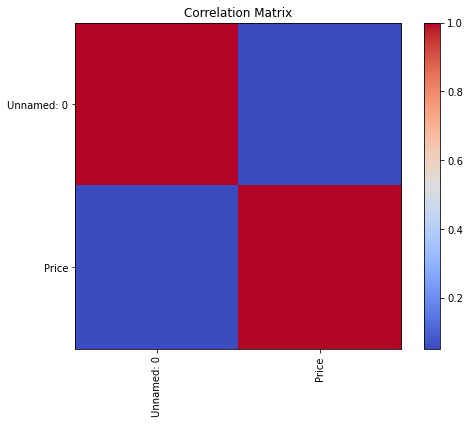

In [33]:
plt.figure(figsize=(8,6))                              #Correlation Heatmap

plt.imshow(corr, cmap="coolwarm", interpolation="nearest")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

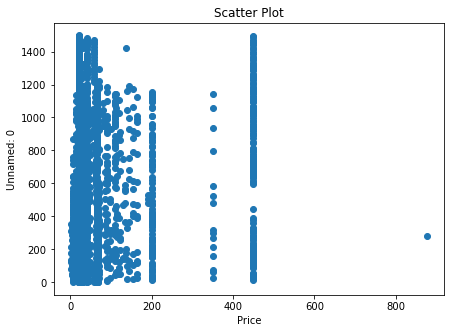

In [39]:
plt.figure(figsize=(7,5))                            #Scatter Plot
 
plt.scatter(df["Price"], df["Unnamed: 0"])

plt.xlabel("Price")

plt.ylabel("Unnamed: 0")

plt.title("Scatter Plot")

plt.show()

In [41]:
df.head()                                      #Final Dataset

,Unnamed: 0,Organisation,Location,Datetime,Details,Rocket_Status,Price,Mission_Status
0,0,VKS RF,"Site 43/4, Plesetsk Cosmodrome, Russia",2024-02-09 07:03:00+00:00,Soyuz 2.1v | Cosmos 2575,Active,NaN,Success
1,1,SpaceX,"SLC-40, Cape Canaveral SFS, Florida, USA",2024-02-08 06:33:00+00:00,Falcon 9 Block 5 | PACE,Active,67.0,Success
2,2,CASC,"Bo Run Jiu Zhou Barge (Area 2), China Coastal ...",2024-02-03 03:06:00+00:00,Jielong-3 | 9 satellites,Active,NaN,Success
3,3,CASC,"LC-3, Xichang Satellite Launch Center, China",2024-02-02 23:37:00+00:00,Long March 2C | Geely Constellation Group 02,Active,30.8,Success
4,4,Rocket Lab,"Rocket Lab LC-1B, Māhia Peninsula, New Zealand",2024-01-31 06:34:00+00:00,Electron/Curie | Four Of A Kind,Active,7.5,Success
